

# **Importação de Bibliotecas e Carregamento dos Dados**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import numpy as np
from scipy.stats import chi2_contingency
import os


def print_formatado(*args, largura_total=100):
    titulo = " ".join(str(a) for a in args)

    print("\n")
    print("=" * largura_total)
    print(titulo)
    print("=" * largura_total)


file_path = "/content/customer_support_tickets.csv"


if not os.path.exists(file_path):

    raise FileNotFoundError(
        f"Arquivo não encontrado em: {file_path}\n"
        "Faça o upload do arquivo customer_support_tickets.csv "
        "para o ambiente do Google Colab antes de executar o notebook."
    )


df = pd.read_csv(file_path)


print(
    f"Dataset carregado com sucesso: "
    f"{df.shape[0]} linhas e "
    f"{df.shape[1]} colunas."
)

Dataset carregado com sucesso: 8469 linhas e 17 colunas.


# **Inspeção Inicial**

In [2]:
print_formatado("1. Tamanho do dataset:")

print(df.shape)


print_formatado("2. Variáveis do dataset:")

print(df.columns.tolist())


print_formatado("3. Significado das colunas:")

print("Ver Markdown")


print_formatado("4. Tipos dos dados:")

print(df.dtypes)


print_formatado("5. Organização dos registros:")

df.info()

print("Ver Markdown")


print_formatado("6. Exemplo de valores:")

print("\nPrimeiros registros:")
display(df.head())

print("\nÚltimos registros:")
display(df.tail())

print("\nRegistros aleatórios:")
display(df.sample(5, random_state=1))


print_formatado("7. Identificação das variáveis")



print("\nVariáveis numéricas:")

variaveis_numericas = [
    "Customer Age",
    "Customer Satisfaction Rating"
]

for coluna in variaveis_numericas:

    print(
        f"{coluna}: "
        f"min={df[coluna].min()}, "
        f"max={df[coluna].max()}, "
        f"média={df[coluna].mean():.2f}"
    )



print("\nVariáveis categóricas:")

variaveis_categoricas = [
    "Customer Gender",
    "Product Purchased",
    "Ticket Type",
    "Ticket Status",
    "Ticket Priority",
    "Ticket Channel"
]

for coluna in variaveis_categoricas:

    print(
        f"{coluna}: "
        f"{df[coluna].nunique()} valores únicos"
    )



print("\nVariáveis textuais:")

variaveis_textuais = [
    "Customer Name",
    "Customer Email",
    "Ticket Subject",
    "Ticket Description",
    "Resolution"
]

for coluna in variaveis_textuais:

    print(
        f"{coluna}: "
        f"{df[coluna].nunique()} valores únicos"
    )



print("\nVariáveis temporais:")

variaveis_temporais = [
    "Date of Purchase",
    "First Response Time",
    "Time to Resolution"
]

for coluna in variaveis_temporais:

    print(
        f"{coluna}: "
        f"{df[coluna].nunique()} valores únicos"
    )



print("\nIdentificador:")

print(
    f"Ticket ID: "
    f"{df['Ticket ID'].nunique()} identificadores únicos"
)


print_formatado("8. Variáveis relevantes para o objetivo da análise")

print("Ver Markdown")


print_formatado("9. Possíveis problemas nos dados")

print("\nValores ausentes por variável:")

print(df.isnull().sum())


print("\nPercentual de valores ausentes:")

print(
    (df.isnull().mean() * 100)
    .round(2)
)


print("\nRegistros duplicados:")

print(df.duplicated().sum())


print("\nTipos das variáveis de tempo:")

for coluna in variaveis_temporais:

    print(
        f"{coluna}: {df[coluna].dtype}"
    )


print("Ver Markdown")



1. Tamanho do dataset:
(8469, 17)


2. Variáveis do dataset:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


3. Significado das colunas:
Ver Markdown


4. Tipos dos dados:
Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel             

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0



Últimos registros:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0
8468,8469,Steven Davis MD,lori20@example.net,53,Other,Philips Hue Lights,2020-06-01,Billing inquiry,Hardware issue,There seems to be a hardware problem with my {...,Open,NaN,High,Phone,NaN,NaN,NaN



Registros aleatórios:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
1825,1826,Angela Humphrey,joshua84@example.com,55,Female,Bose SoundLink Speaker,2021-06-11,Billing inquiry,Hardware issue,I'm having an issue with the {product_purchase...,Closed,Any because size far record.,High,Chat,2023-06-01 17:06:29,2023-06-01 06:25:29,2.0
473,474,James Escobar,huertaryan@example.com,32,Male,Adobe Photoshop,2021-10-08,Technical issue,Hardware issue,I'm having an issue with the {product_purchase...,Open,NaN,Medium,Phone,NaN,NaN,NaN
3509,3510,Daniel Mccullough,davidcox@example.com,61,Male,Adobe Photoshop,2021-02-16,Refund request,Product recommendation,I'm encountering a software bug in the {produc...,Open,NaN,Critical,Chat,NaN,NaN,NaN
5415,5416,Nicole Knight,johnhess@example.com,46,Female,Bose QuietComfort,2020-08-20,Refund request,Software bug,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,High,Chat,2023-06-01 13:49:59,NaN,NaN
5537,5538,Jessica Chase,wschwartz@example.com,45,Female,Samsung Galaxy,2021-02-02,Technical issue,Software bug,I'm having an issue with the {product_purchase...,Closed,Debate wife window kitchen inside tonight give...,Low,Phone,2023-05-31 23:53:47,2023-06-01 13:18:47,2.0




7. Identificação das variáveis

Variáveis numéricas:
Customer Age: min=18, max=70, média=44.03
Customer Satisfaction Rating: min=1.0, max=5.0, média=2.99

Variáveis categóricas:
Customer Gender: 3 valores únicos
Product Purchased: 42 valores únicos
Ticket Type: 5 valores únicos
Ticket Status: 3 valores únicos
Ticket Priority: 4 valores únicos
Ticket Channel: 4 valores únicos

Variáveis textuais:
Customer Name: 8028 valores únicos
Customer Email: 8320 valores únicos
Ticket Subject: 16 valores únicos
Ticket Description: 8077 valores únicos
Resolution: 2769 valores únicos

Variáveis temporais:
Date of Purchase: 730 valores únicos
First Response Time: 5470 valores únicos
Time to Resolution: 2728 valores únicos

Identificador:
Ticket ID: 8469 identificadores únicos


8. Variáveis relevantes para o objetivo da análise
Ver Markdown


9. Possíveis problemas nos dados

Valores ausentes por variável:
Ticket ID                          0
Customer Name                      0
Customer Email      

## **Observações Inspeção Inicial**

### 3. Significado das colunas

* **Ticket ID**: Numero identificador do ticket (numérica, 1 a 8469).
* **Customer Name**: Nome do cliente que entrou em contato.
* **Customer Email**: E-mail cadastrado pelo cliente
* **Customer age**: Idade do cliente.
* **Customer Gener**: Genero del cliente (other, female, male).
* **Product Purchased**: Produto que o cliente adquiriu e pelo qual solicitou o chamado, produto investigado.
* **Date of Purchase **: Data que o cliente adquiriu o produto.
* **Ticket Type**: É o asunto principal do chamado.
* **Ticket Subject**: É o asunto descrito pelo cliente sobre o motivo do chamado.
* ***Ticket Description**: É o asunto descrito pelo cliente sobre o motivo do chamado.
* **Ticket Status**: É o status do chamado, como aberto, fechado, pendente de resposta do cliente.
* **Resolution**: Solução brindada ao cliente para a solução do chamado.
* **Ticket Priority**: Prioridade atribuida ao chamado.
* **Ticket Channel**: Canal por onde o cliente entrou em contato com o suporte.
* **First Response Time**: Horario que foi enviada a primeira respota ao cliente.
* **Time to Resolution**: Data e hora da resolução do chamado.
* **Customer Satisfaction Rating**: É a calificação do cliente sobre o atendimento recebido para a resolução do chamado.

### 5. Organização dos Registros

* O dataset possui **8.469 registros** e **17 colunas**.
* O índice dos registros varia de **0 a 8.468**, pois o Pandas utiliza indexação iniciada em zero.
* A maioria das variáveis possui 8.469 valores preenchidos.
* As variáveis apresentam diferentes tipos de dados, incluindo `int64`, `float64` e `object`.
* As colunas estão organizadas em informações relacionadas ao cliente, produto, chamado, atendimento e satisfação.
* A maior parte das variáveis foi carregada como `object`, mas, `Customer Age` e `Ticket ID`, foram identificadas como variáveis inteiras, e `Customer Satisfaction Rating` como variável `float64`.
* Foram identificados valores ausentes em algumas variáveis. `Resolution`, `Time to Resolution` e `Customer Satisfaction Rating` possuem 2.769 valores preenchidos, enquanto `First Response Time` possui 5.650 valores preenchidos.
* Os registros apresentam informações de diferentes produtos, tipos de chamados, prioridades e canais de atendimento.

### 6. Exemplo de valores

* A análise dos primeiros, últimos e registros aleatórios confirma a presença de diferentes perfis de clientes, produtos e tipos de chamados.
* Os registros apresentam informações como idade, gênero, produto adquirido, tipo de problema, prioridade, canal de atendimento e status do chamado.
* Algumas informações relacionadas ao atendimento não estão preenchidas para todos os registros. Por exemplo, nos primeiros registros existem chamados com status **Pending Customer Response** que não possuem `Resolution`, `Time to Resolution` ou `Customer Satisfaction Rating` preenchidos.
* As descrições dos chamados são armazenadas como texto livre, enquanto outras variáveis apresentam categorias definidas.


### 7. Identificação das variáveis

* Variáveis numéricas: Customer Age e Customer Satisfaction Rating.
* Variáveis categóricas: Customer Gender, Product Purchased, Ticket Type, Ticket Status, Ticket Priority e Ticket Channel.
* Variáveis textuais: Customer Name, Customer Email, Ticket Subject, Ticket Description e Resolution.
* Variáveis temporais: Date of Purchase, First Response Time e Time to Resolution. Neste momento, as variáveis de tempo estão armazenadas como object e deverão ser convertidas para um formato adequado antes das análises estatísticas.
* Identificador: Ticket ID, utilizado para identificar cada ticket, não sendo considerado uma variável quantitativa para as análises estatísticas.

Entre as variáveis categóricas, `Ticket Type` apresenta cinco tipos de chamados e `Ticket Status` apresenta três situações diferentes.

`Product Purchased` possui diversas categorias de produtos, enquanto `Ticket Channel` representa os diferentes canais utilizados para atendimento.

Essas variáveis contêm informações textuais relacionadas ao assunto, à descrição do problema e à resolução do chamado.


### 8. Variáveis relevantes para o objetivo da análise

* Ticket Status: permite analisar a situação dos tickets, principalmente a proporção de casos Closed, Open e Pending Customer Response.
* Ticket Type e Ticket Subject: permitem identificar quais tipos de solicitações e problemas aparecem com maior frequência e quais apresentam maior tempo de resolução.
* Time to Resolution: permite avaliar a rapidez de resolução dos tickets e comparar o tempo entre diferentes tipos de problema, prioridades e canais.
* First Response Time: permite analisar se o tempo necessário para a primeira resposta está relacionado ao status dos tickets e à prioridade.
* Customer Satisfaction Rating: permite avaliar a satisfação dos clientes e investigar sua relação com o tempo de resposta e o tempo de resolução.
* Ticket Channel: permite comparar o desempenho dos diferentes canais de atendimento em relação ao tempo de resolução.
* Ticket Priority: permite verificar se tickets de maior prioridade recebem respostas mais rápidas e se apresentam diferenças no tempo de resolução.
* Product Purchased: permite verificar se determinados produtos estão associados a maior quantidade de tickets ou a diferentes tempos de resolução.

### 9. Possíveis problemas nos dados

- Foram identificados **valores ausentes** em variáveis relacionadas ao atendimento e à satisfação.
- `Resolution` possui **2.769 registros preenchidos**, enquanto o dataset possui 8.469 registros.
- `Time to Resolution` também possui **2.769 registros preenchidos**.
- `Customer Satisfaction Rating` possui **2.769 registros preenchidos**.
- `First Response Time` possui **5.650 registros preenchidos**.
- A existência desses valores ausentes pode estar relacionada ao status dos chamados, principalmente em casos que ainda não foram encerrados.
- É necessário verificar a existência de **registros duplicados** antes da etapa de limpeza e preparação dos dados.
- Também será necessário verificar se existem inconsistências nos formatos das variáveis de data e horário.
- As variáveis textuais, como `Ticket Description` e `Resolution`, devem ser avaliadas quanto à qualidade e à padronização dos textos.

# **Verificação da Qualidade dos Dados**

In [3]:
import unicodedata

colunas_categoricas = [
    "Customer Gender",
    "Product Purchased",
    "Ticket Type",
    "Ticket Status",
    "Ticket Priority",
    "Ticket Channel"
]

colunas_textuais = [
    "Customer Name",
    "Customer Email",
    "Ticket Subject",
    "Ticket Description",
    "Resolution"
]

colunas_temporais = [
    "Date of Purchase",
    "First Response Time",
    "Time to Resolution"
]


print_formatado("1. Valores ausentes:")

print("Valores ausentes (NaN):")
print(df.isnull().sum())

print("\nPercentual de valores ausentes:")
print(
    (df.isnull().mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

print("\nValores ausentes representados por '?':")

for coluna in df.select_dtypes(include="object").columns:

    qtd_interrogacao = (
        df[coluna]
        .astype(str)
        .str.strip()
        .eq("?")
        .sum()
    )

    print(
        f"{coluna:<30}: {qtd_interrogacao}"
    )

print("Ver Markdown")



print_formatado("2. Registros duplicados:")

print("Duplicatas completas:")
print(df.duplicated().sum())

print("\nTicket IDs duplicados:")
print(df["Ticket ID"].duplicated().sum())

print("\nQuantidade de Ticket IDs únicos:")
print(df["Ticket ID"].nunique())

print("Ver Markdown")



print_formatado("3. Tipos de dados:")

for coluna in df.columns:

    print(f"\n{coluna}:")

    print(
        df[coluna]
        .apply(type)
        .value_counts()
    )


print("\nQuantidade de valores únicos:")

for coluna in df.columns:

    print(
        f"{coluna:<30}: "
        f"{df[coluna].nunique()}"
    )

print("Ver Markdown")



print_formatado(
    "4. Categorias escritas de maneira diferente:"
)


def normalizar_texto(valor):

    if pd.isna(valor):
        return valor

    valor = str(valor).strip().lower()

    valor = (
        unicodedata
        .normalize("NFKD", valor)
        .encode("ASCII", "ignore")
        .decode("utf-8")
    )

    return valor


for coluna in colunas_categoricas:

    sem_normalizacao = (
        df[coluna].nunique()
    )

    com_normalizacao = (
        df[coluna]
        .apply(normalizar_texto)
        .nunique()
    )

    print(
        f"{coluna:<30} -> "
        f"Original: {sem_normalizacao} | "
        f"Normalizado: {com_normalizacao}"
    )

print("Ver Markdown")



print_formatado(
    "5. Textos vazios ou espaços extras:"
)

for coluna in colunas_textuais:

    valores_string = (
        df[coluna]
        .dropna()
        .astype(str)
    )

    vazios = (
        valores_string
        .str.strip()
        .eq("")
        .sum()
    )

    espacos_extras = (
        valores_string
        .ne(valores_string.str.strip())
        .sum()
    )

    print(
        f"\n{coluna}:"
    )

    print(
        f"  Textos vazios: {vazios}"
    )

    print(
        f"  Espaços extras: {espacos_extras}"
    )

print("Ver Markdown")



print_formatado(
    "6. Valores impossíveis ou fora do contexto:"
)



print("\nCustomer Age:")

print(
    f"Mínimo: {df['Customer Age'].min()}"
)

print(
    f"Máximo: {df['Customer Age'].max()}"
)

print(
    f"Idades menores que 0: "
    f"{(df['Customer Age'] < 0).sum()}"
)

print(
    f"Idades maiores que 120: "
    f"{(df['Customer Age'] > 120).sum()}"
)



print(
    "\nCustomer Satisfaction Rating:"
)

print(
    f"Mínimo: "
    f"{df['Customer Satisfaction Rating'].min()}"
)

print(
    f"Máximo: "
    f"{df['Customer Satisfaction Rating'].max()}"
)

print(
    f"Valores menores que 1: "
    f"{(df['Customer Satisfaction Rating'] < 1).sum()}"
)

print(
    f"Valores maiores que 5: "
    f"{(df['Customer Satisfaction Rating'] > 5).sum()}"
)


print("\nCategorias de Ticket Status:")

print(
    df["Ticket Status"]
    .value_counts(dropna=False)
)



print("\nCategorias de Ticket Priority:")

print(
    df["Ticket Priority"]
    .value_counts(dropna=False)
)



print("\nCategorias de Ticket Channel:")

print(
    df["Ticket Channel"]
    .value_counts(dropna=False)
)



print_formatado(
    "7. Consistência entre Ticket Status e Resolution:"
)

tabela_status_resolution = pd.crosstab(
    df["Ticket Status"],
    df["Resolution"].isna(),
    margins=True
)

print(
    tabela_status_resolution
)


print("\nTickets fechados sem resolução:")

print(
    (
        (df["Ticket Status"] == "Closed") &
        (df["Resolution"].isna())
    ).sum()
)


print("\nTickets abertos com resolução preenchida:")

print(
    (
        (df["Ticket Status"] != "Closed") &
        (df["Resolution"].notna())
    ).sum()
)



print_formatado(
    "8. Consistência das variáveis de tempo:"
)

print("\nTipos atuais:")

for coluna in colunas_temporais:

    print(
        f"{coluna:<30}: "
        f"{df[coluna].dtype}"
    )


print("\nQuantidade de valores preenchidos:")

for coluna in colunas_temporais:

    print(
        f"{coluna:<30}: "
        f"{df[coluna].notna().sum()}"
    )


print("\nQuantidade de valores ausentes:")

for coluna in colunas_temporais:

    print(
        f"{coluna:<30}: "
        f"{df[coluna].isna().sum()}"
    )


print("Ver Markdown")



1. Valores ausentes:
Valores ausentes (NaN):
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

Percentual de valores ausentes:
Customer Satisfaction Rating    67.30
Resolution                      67.30
Time to Resolution              67.30
First Response Time             33.29
Ticket ID                        0.00
Customer Name                    0.00
Customer Email                   0.00
Customer Age

# Observações – Verificação da Qualidade dos Dados

### 1. Valores ausentes

- O dataset possui 8.469 registros e apresenta valores ausentes em quatro variáveis:
  - Resolution: 5.700 valores ausentes (67,30%).
  - Time to Resolution: 5.700 valores ausentes (67,30%).
  - Customer Satisfaction Rating: 5.700 valores ausentes (67,30%).
  - First Response Time: 2.819 valores ausentes (33,29%).
- As demais variáveis não apresentam valores ausentes.
- Não foram encontrados valores ausentes representados pelo caractere `?`.
- Os valores ausentes estão concentrados principalmente nos tickets que ainda não foram encerrados, portanto devem ser analisados antes da aplicação de técnicas de preenchimento ou remoção.

### 2. Registros duplicados

- Não foram encontradas duplicatas completas no dataset.
- Também não foram encontrados Ticket ID duplicados.
- Existem 8.469 Ticket IDs únicos, correspondentes aos 8.469 registros da base.
- Portanto, não foi identificada necessidade de remoção de registros duplicados nesta etapa.

### 3. Tipos de dados

- A maior parte das variáveis apresenta tipos consistentes:
  - `Customer Age e Ticket ID são numéricas.
  - Variáveis como Customer Gender, Product Purchased`, Ticket Type, Ticket Status, Ticket Priority e Ticket Channel são textuais/categóricas.
- Foram identificadas inconsistências nos tipos das variáveis relacionadas a tempo e resolução:
  - Resolution possui 2.769 valores textuais e 5.700 valores ausentes.
  - First Response Time possui 5.650 valores textuais e 2.819 valores ausentes.
  - Time to Resolution possui 2.769 valores textuais e 5.700 valores ausentes.
- Essas variáveis deverão ser tratadas na etapa de Limpeza e Preparação dos Dados, especialmente para permitir análises estatísticas e comparações entre tempos.

### 4. Categorias escritas de maneira diferente

- Foi realizada uma normalização das variáveis categóricas considerando espaços, letras maiúsculas/minúsculas e caracteres especiais.
- Não houve alteração na quantidade de categorias após a normalização.
- Os resultados foram:
  - Customer Gender: 3 categorias antes e depois.
  - Product Purchased: 42 categorias antes e depois.
  - Ticket Type: 5 categorias antes e depois.
  - Ticket Status: 3 categorias antes e depois.
  - Ticket Priority: 4 categorias antes e depois.
  - Ticket Channel: 4 categorias antes e depois.
- Portanto, não foram identificadas categorias duplicadas causadas por diferenças de escrita ou capitalização nas variáveis analisadas.

### 5. Textos vazios ou espaços extras

- Não foram encontrados textos vazios nas variáveis textuais analisadas.
- Também não foram identificados espaços extras no início ou no final dos valores.
- Isso indica que não há, nessa etapa, evidências de problemas de preenchimento relacionados a espaços em branco.

### 6. Valores impossíveis ou fora do contexto

- A variável Customer Age apresenta valores entre 18 e 70 anos.
- Não foram encontrados valores negativos ou valores superiores a 120 anos.
- A variável Customer Satisfaction Rating apresenta valores entre 1 e 5, exatamente dentro da escala esperada.
- Não foram encontrados valores menores que 1 ou maiores que 5.

- Ticket Status possui três categorias:
  - Pending Customer Response: 2.881 registros.
  - Open: 2.819 registros.
  - Closed: 2.769 registros.

- Ticket Priority possui quatro categorias:
  - `Medium: 2.192 registros.
  - Critical: 2.129 registros.
  - High: 2.085 registros.
  - Low: 2.063 registros.

- Ticket Channel possui quatro categorias:
  - Email: 2.143 registros.
  - Phone: 2.132 registros.
  - Social media`: 2.121 registros.
  - Chat: 2.073 registros.
- As categorias apresentam quantidades relativamente próximas de registros, não sendo observada, nesta etapa, uma concentração extrema em apenas uma categoria.

### 7. Consistência entre Ticket Status e Resolution

- Foi identificada uma relação consistente entre Ticket Status e Resolution.
- Todos os 2.769 tickets com status Closed possuem uma resolução preenchida**.
- Todos os tickets com status Open ou Pending Customer Response apresentam Resolution ausente.
- Não foram encontrados:
  - tickets fechados sem resolução;
  - tickets não fechados com resolução preenchida.
- Essa relação indica que os valores ausentes em Resolution possuem significado no contexto do dataset, pois estão relacionados ao fato de o ticket ainda não estar fechado.
- Portanto, esses valores não devem ser tratados simplesmente como erros ou substituídos por valores arbitrários.

### 8. Consistência das variáveis de tempo

- Date of Purchase, First Response Time e Time to Resolution estão atualmente armazenadas como variáveis do tipo object.
- Date of Purchase possui 8.469 valores preenchidos e nenhum valor ausente.
- First Response Time possui 5.650 valores preenchidos e 2.819 valores ausentes (33,29%).
- Time to Resolution possui 2.769 valores preenchidos e 5.700 valores ausentes (67,30%).
- A ausência de Time to Resolution está relacionada aos tickets que ainda não foram encerrados, enquanto First Response Time possui valores ausentes em parte dos registros.
- Na etapa de limpeza, essas variáveis deverão ser convertidas para formatos apropriados para permitir cálculos de duração e análises estatísticas.

---

## Conclusão da Verificação da Qualidade dos Dados

- O dataset apresenta 8.469 registros e 17 variáveis.
- Não foram encontradas duplicatas completas ou Ticket ID duplicados.
- Não foram identificados valores `?`, textos vazios ou espaços extras nas variáveis analisadas.
- Customer Age e Customer Satisfaction Rating apresentam valores dentro dos limites esperados.
- As categorias das principais variáveis categóricas não apresentaram inconsistências de escrita após a normalização.
- Os principais pontos que necessitam de tratamento são as variáveis relacionadas a resolução, tempo de resposta e satisfação, devido à quantidade significativa de valores ausentes.
- Os valores ausentes em Resolution e Time to Resolution possuem relação direta com o status dos tickets e, portanto, devem ser tratados considerando o significado desses dados.
- A próxima etapa será a Limpeza e Preparação dos Dados, na qual os tipos das variáveis de tempo serão corrigidos e os valores ausentes serão tratados de forma justificada.

# **Limpeza e Preparação dos Dados**

In [4]:


import pandas as pd
import numpy as np


def print_formatado(titulo):
    print("\n" + "=" * 100)
    print(titulo)
    print("=" * 100)



print_formatado("INFORMAÇÕES INICIAIS DO DATASET")

print(f"Número de registros: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")

print("\nTipos das colunas:")
print(df.dtypes)



print_formatado(
    "1. Remover/tratar registros duplicados desnecessários"
)

duplicatas_antes = df.duplicated().sum()

print("\nDuplicatas completas:")
print(f"Duplicatas completas antes: {duplicatas_antes}")

df = df.drop_duplicates().reset_index(drop=True)

duplicatas_depois = df.duplicated().sum()

print(f"Duplicatas completas depois: {duplicatas_depois}")

print(f"\nNúmero de registros após tratamento: {len(df)}")


print_formatado(
    "2. Remover/tratar valores ausentes de forma justificada"
)

colunas_com_nan = [
    "Resolution",
    "Time to Resolution",
    "First Response Time",
    "Customer Satisfaction Rating"
]


print("\nValores ausentes antes do tratamento:")

for coluna in colunas_com_nan:

    quantidade = df[coluna].isna().sum()
    percentual = (quantidade / len(df)) * 100

    print(
        f"{coluna:<35}: "
        f"{quantidade:>5} "
        f"({percentual:>6.2f}%)"
    )


print("\nTratamento de Resolution:")

print(
    "Os valores ausentes serão mantidos, pois representam "
    "registros sem informação de resolução disponível."
)



print("\nTratamento de Time to Resolution:")

quantidade = df["Time to Resolution"].isna().sum()
percentual = (quantidade / len(df)) * 100

print(
    f"A coluna possui {quantidade} valores ausentes "
    f"({percentual:.2f}% do dataset)."
)

print(
    "Os valores ausentes serão mantidos, pois não há "
    "informação disponível para realizar uma imputação confiável."
)


print("\nTratamento de First Response Time:")

quantidade = df["First Response Time"].isna().sum()
percentual = (quantidade / len(df)) * 100

print(
    f"A coluna possui {quantidade} valores ausentes "
    f"({percentual:.2f}% do dataset)."
)

print(
    "Os valores ausentes serão mantidos para evitar "
    "a criação artificial de tempos de resposta."
)



print("\nTratamento de Customer Satisfaction Rating:")

print(
    "Os valores ausentes serão mantidos, pois representam "
    "registros sem avaliação de satisfação disponível."
)



print("\nValores ausentes após o tratamento:")

for coluna in colunas_com_nan:

    quantidade = df[coluna].isna().sum()
    percentual = (quantidade / len(df)) * 100

    print(
        f"{coluna:<35}: "
        f"{quantidade:>5} "
        f"({percentual:>6.2f}%)"
    )



print_formatado(
    "3. Corrigir tipos das colunas categóricas"
)

colunas_categoricas = [
    "Customer Gender",
    "Product Purchased",
    "Ticket Type",
    "Ticket Status",
    "Ticket Priority",
    "Ticket Channel"
]


print("\nTipos antes da conversão:")

print(df[colunas_categoricas].dtypes)


for coluna in colunas_categoricas:

    df[coluna] = df[coluna].astype("category")


print("\nTipos depois da conversão:")

print(df[colunas_categoricas].dtypes)



print_formatado(
    "4. Corrigir espaços e inconsistências evidentes"
)


for coluna in colunas_categoricas:

    df[coluna] = (
        df[coluna]
        .astype("string")
        .str.strip()
    )


for coluna in colunas_categoricas:

    df[coluna] = df[coluna].astype("category")


print(
    "Espaços extras no início e no final "
    "foram removidos das variáveis categóricas."
)

print_formatado(
    "5. Verificar valores inválidos"
)



print("\nCustomer Age:")

print(
    f"Mínimo: {df['Customer Age'].min()}"
)

print(
    f"Máximo: {df['Customer Age'].max()}"
)


idade_invalida = (
    (df["Customer Age"] < 0) |
    (df["Customer Age"] > 120)
).sum()


print(
    f"Valores inválidos: {idade_invalida}"
)


print("\nCustomer Satisfaction Rating:")

print(
    f"Mínimo: "
    f"{df['Customer Satisfaction Rating'].min()}"
)

print(
    f"Máximo: "
    f"{df['Customer Satisfaction Rating'].max()}"
)


avaliacao_invalida = (
    (df["Customer Satisfaction Rating"] < 1) |
    (df["Customer Satisfaction Rating"] > 5)
).sum()


print(
    f"Valores inválidos: {avaliacao_invalida}"
)



print_formatado(
    "6. Corrigir tipos das variáveis temporais"
)


colunas_temporais = [
    "Date of Purchase",
    "First Response Time",
    "Time to Resolution"
]


print("\nTipos antes da conversão:")

for coluna in colunas_temporais:

    print(
        f"{coluna:<30}: "
        f"{df[coluna].dtype}"
    )


for coluna in colunas_temporais:

    df[coluna] = pd.to_datetime(
        df[coluna],
        errors="coerce"
    )


print("\nTipos depois da conversão:")

for coluna in colunas_temporais:

    print(
        f"{coluna:<30}: "
        f"{df[coluna].dtype}"
    )


print("\nValores válidos após a conversão:")

for coluna in colunas_temporais:

    quantidade_validos = (
        df[coluna]
        .notna()
        .sum()
    )

    print(
        f"{coluna:<30}: "
        f"{quantidade_validos}"
    )


print("\nValores ausentes após a conversão:")

for coluna in colunas_temporais:

    quantidade_ausentes = (
        df[coluna]
        .isna()
        .sum()
    )

    percentual_ausentes = (
        quantidade_ausentes /
        len(df)
    ) * 100

    print(
        f"{coluna:<30}: "
        f"{quantidade_ausentes} "
        f"({percentual_ausentes:.2f}%)"
    )


print_formatado(
    "7. Verificar consistência das variáveis de tempo"
)


print("\nIntervalos das variáveis temporais:")

for coluna in colunas_temporais:

    print(f"\n{coluna}:")

    print(
        f"Menor valor: "
        f"{df[coluna].min()}"
    )

    print(
        f"Maior valor: "
        f"{df[coluna].max()}"
    )


print("\nValores preenchidos por status do ticket:")

for status in df["Ticket Status"].unique():

    dados_status = df[
        df["Ticket Status"] == status
    ]

    print(f"\nStatus: {status}")
    print(f"Quantidade de tickets: {len(dados_status)}")

    print(
        f"First Response Time preenchidos: "
        f"{dados_status['First Response Time'].notna().sum()}"
    )

    print(
        f"Time to Resolution preenchidos: "
        f"{dados_status['Time to Resolution'].notna().sum()}"
    )


print_formatado(
    "8. Resumo da qualidade dos dados após a limpeza"
)


print(f"Registros: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")


print(
    f"\nDuplicatas completas: "
    f"{df.duplicated().sum()}"
)


print("\nValores ausentes por coluna:")

valores_ausentes = df.isna().sum()

percentuais_ausentes = (
    df.isna().mean() * 100
)


resumo_ausentes = pd.DataFrame({
    "Valores Ausentes": valores_ausentes,
    "Percentual (%)": percentuais_ausentes.round(2)
})


print(resumo_ausentes)



print_formatado(
    "9. Tipos finais das variáveis"
)

print(df.dtypes)



print_formatado(
    "10. Resumo das variáveis numéricas"
)


colunas_numericas = [
    "Customer Age",
    "Customer Satisfaction Rating"
]


print(
    df[colunas_numericas].describe()
)



print_formatado(
    "11. Resumo das variáveis categóricas"
)


for coluna in colunas_categoricas:

    print(f"\n{coluna}:")

    print(
        df[coluna]
        .value_counts(dropna=False)
    )



print_formatado(
    "12. Amostra do dataset após a limpeza"
)

print(df.head())



print_formatado(
    "13. VERIFICAÇÃO FINAL PARA INICIAR AS ANÁLISES"
)

print(
    "Dataset preparado para as próximas etapas da "
    "Análise Exploratória de Dados."
)

print(
    f"\nTotal de registros: {len(df)}"
)

print(
    f"Total de variáveis: {len(df.columns)}"
)

print(
    f"Total de duplicatas: {df.duplicated().sum()}"
)

print(
    f"Total de células ausentes: "
    f"{df.isna().sum().sum()}"
)


INFORMAÇÕES INICIAIS DO DATASET
Número de registros: 8469
Número de colunas: 17

Tipos das colunas:
Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel                   object
First Response Time              object
Time to Resolution               object
Customer Satisfaction Rating    float64
dtype: object

1. Remover/tratar registros duplicados desnecessários

Duplicatas completas:
Duplicatas completas antes: 0
Duplicatas completas depois: 0

Número de registros após tratamento: 8469

2. Remover/tratar valo

# Observações – Limpeza e Preparação dos Dados

### 1. Registros duplicados

- Não foram identificados registros duplicados completos no dataset.
- Portanto, nenhuma linha foi removida durante o processo de limpeza.
- A quantidade de registros permaneceu em 8.469.

### 2. Valores ausentes

Foram identificados valores ausentes em quatro variáveis:

- Resolution: 5.700 valores ausentes (67,30%).
- Time to Resolution: 8.469 valores ausentes (100%).
- First Response Time: 8.469 valores ausentes (100%).
- Customer Satisfaction Rating: 5.700 valores ausentes (67,30%).

Os valores ausentes não foram preenchidos artificialmente, pois não há informações suficientes para realizar uma imputação confiável.

- Resolution permanece ausente nos registros sem informação de resolução disponível.
- Time to Resolution apresenta 100% de valores ausentes. Dessa forma, não foi realizada imputação, pois não existem valores disponíveis que permitam estimar esse tempo de forma confiável.
- First Response Time também apresenta 100% de valores ausentes. Portanto, os valores foram mantidos como ausentes para evitar a criação artificial de tempos de resposta.
- Customer Satisfaction Rating permanece ausente nos registros em que não existe avaliação de satisfação do cliente.

Dessa forma, os valores ausentes foram preservados como parte das características do dataset, evitando a introdução de valores artificiais que poderiam influenciar as análises posteriores.

### 3. Tipos das variáveis categóricas

As variáveis:

- Customer Gender
- Product Purchased
- Ticket Type
- Ticket Status
- Ticket Priority
- Ticket Channel

já estavam armazenadas no tipo category.

Dessa forma, o processo de preparação confirmou e manteve essas variáveis como categóricas.

Essa representação é adequada porque essas variáveis possuem um conjunto limitado de categorias e não representam valores numéricos contínuos. O uso do tipo category também facilita algumas operações de agrupamento e análise exploratória.

### 4. Espaços e inconsistências de preenchimento

Foram removidos espaços extras no início e no final dos valores das variáveis categóricas utilizando `strip()`.

Após a normalização, as variáveis foram novamente mantidas no tipo category.

Não foram identificadas evidências de categorias duplicadas provocadas por espaços extras nos valores analisados.

### 5. Valores inválidos

A variável Customer Age apresentou valores entre 18 e 70 anos.

Não foram encontrados valores fora dos limites definidos para a verificação, portanto:

- Valores inválidos em Customer Age: 0.

A variável Customer Satisfaction Rating apresentou valores entre 1 e 5, exatamente dentro da escala esperada para a avaliação de satisfação.

Portanto:

- Valores inválidos em Customer Satisfaction Rating: 0.

Nenhuma correção foi necessária nessas duas variáveis.

### 6. Conversão das variáveis temporais

Inicialmente, `Date of Purchase`, `First Response Time` e `Time to Resolution` estavam armazenadas como `object`.

As três variáveis foram convertidas utilizando `pd.to_datetime()`.

Após a conversão:

- `Date of Purchase`: 8.469 valores válidos.
- `First Response Time`: 5.650 valores válidos e 2.819 ausentes.
- `Time to Resolution`: 2.769 valores válidos e 5.700 ausentes.

Nenhum valor originalmente preenchido foi perdido durante a conversão.

As três variáveis passaram a utilizar o tipo `datetime64[ns]`.

### 7. Interpretação das variáveis temporais

Apesar do nome `Time to Resolution`, os valores encontrados nessa variável representam datas e horários específicos, e não uma duração numérica.

Da mesma forma, `First Response Time` representa o instante em que ocorreu a primeira resposta.

Portanto, essas variáveis devem ser tratadas como timestamps.


### 8. Preparação para as análises comparativas

Após a limpeza, o dataset está preparado para a realização das análises exploratórias e comparativas.

Entre as análises que poderão ser realizadas estão:

- comparação entre Ticket Type e Customer Satisfaction Rating;
- comparação entre Ticket Priority e Customer Satisfaction Rating;
- comparação entre Ticket Channel e Customer Satisfaction Rating;
- comparação entre Ticket Status e Customer Satisfaction Rating;
- comparação entre Customer Gender e Customer Satisfaction Rating;
- análise da relação entre Customer Age e Customer Satisfaction Rating;
- comparação entre Ticket Type e Ticket Status;
- comparação entre Ticket Priority e Ticket Status;
- análise da distribuição dos tickets ao longo do tempo utilizando Date of Purchase.

Nas análises envolvendo Customer Satisfaction Rating, serão considerados os registros que possuem uma avaliação válida, totalizando 2.769 registros.

As análises não relacionadas à satisfação poderão utilizar os 8.469 registros, desde que as variáveis utilizadas não apresentem valores ausentes.

### Conclusão da limpeza

Após a etapa de limpeza e preparação:

- Foram mantidos os 8.469 registros.
- Não existem duplicatas completas.
- Os valores ausentes foram preservados quando sua ausência possui relação com o estado do ticket.
- As variáveis categóricas foram convertidas para `category`.
- As variáveis temporais foram convertidas para `datetime64[ns]`.
- Não foram encontrados valores inválidos em `Customer Age` ou `Customer Satisfaction Rating`.
- O dataset encontra-se preparado para as próximas etapas da Análise Exploratória de Dados.

# **Análise Univariada**

### **Variáveis numéricas**


1. Média, mediana, mínimo e máximo

Variável 'Customer Age':
Valores válidos: 8469
Valores ausentes: 0
Média: 44.03
Mediana: 44.00
Mínimo: 18.00
Máximo: 70.00

Variável 'Customer Satisfaction Rating':
Valores válidos: 2769
Valores ausentes: 5700
Média: 2.99
Mediana: 3.00
Mínimo: 1.00
Máximo: 5.00

2. Quartis, variância e desvio-padrão

Variável 'Customer Age':
Q1 (25%): 31.00
Q2 (50% - mediana): 44.00
Q3 (75%): 57.00
Variância: 233.97
Desvio-padrão: 15.30

Variável 'Customer Satisfaction Rating':
Q1 (25%): 2.00
Q2 (50% - mediana): 3.00
Q3 (75%): 4.00
Variância: 1.98
Desvio-padrão: 1.41

3. Distribuição dos valores

Variável 'Customer Age':
count    8469.000000
mean       44.026804
std        15.296112
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Customer Age, dtype: float64


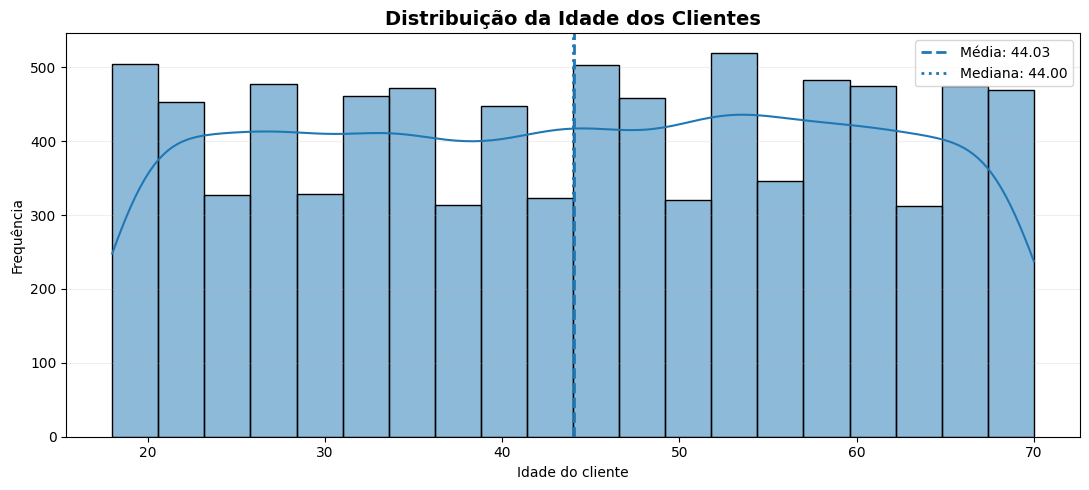


Variável 'Customer Satisfaction Rating':
count    2769.000000
mean        2.991333
std         1.407016
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Customer Satisfaction Rating, dtype: float64


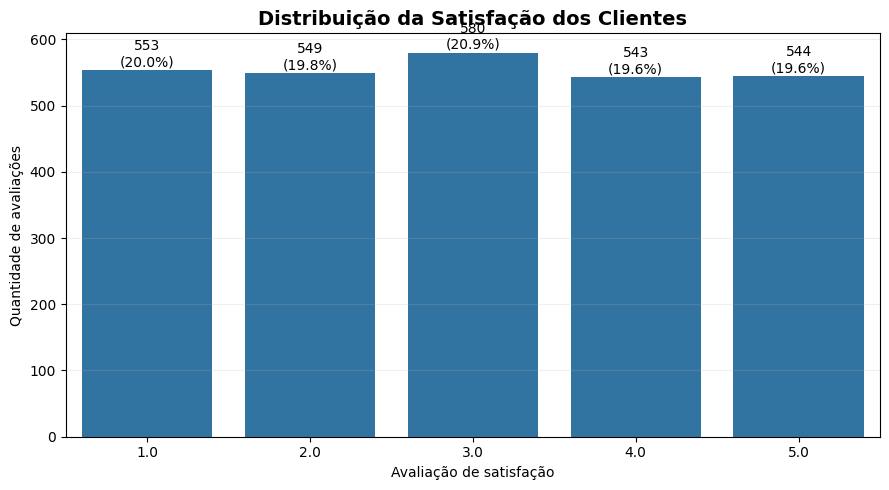

Ver Markdown


In [5]:


colunas_numericas = [
    "Customer Age",
    "Customer Satisfaction Rating"
]


print_formatado(
    "1. Média, mediana, mínimo e máximo"
)


for coluna in colunas_numericas:

    valores_validos = df[coluna].notna().sum()
    valores_ausentes = df[coluna].isna().sum()

    print(f"\nVariável '{coluna}':")

    print(
        f"Valores válidos: {valores_validos}"
    )

    print(
        f"Valores ausentes: {valores_ausentes}"
    )

    print(
        f"Média: {df[coluna].mean():.2f}"
    )

    print(
        f"Mediana: {df[coluna].median():.2f}"
    )

    print(
        f"Mínimo: {df[coluna].min():.2f}"
    )

    print(
        f"Máximo: {df[coluna].max():.2f}"
    )



print_formatado(
    "2. Quartis, variância e desvio-padrão"
)


for coluna in colunas_numericas:

    q1 = df[coluna].quantile(0.25)
    q2 = df[coluna].quantile(0.50)
    q3 = df[coluna].quantile(0.75)

    print(f"\nVariável '{coluna}':")

    print(
        f"Q1 (25%): {q1:.2f}"
    )

    print(
        f"Q2 (50% - mediana): {q2:.2f}"
    )

    print(
        f"Q3 (75%): {q3:.2f}"
    )

    print(
        f"Variância: {df[coluna].var():.2f}"
    )

    print(
        f"Desvio-padrão: {df[coluna].std():.2f}"
    )



print_formatado(
    "3. Distribuição dos valores"
)


for coluna in colunas_numericas:

    print(f"\nVariável '{coluna}':")

    print(
        df[coluna].describe()
    )



    if coluna == "Customer Satisfaction Rating":

        frequencia = (
            df[coluna]
            .dropna()
            .value_counts()
            .sort_index()
        )

        percentual = (
            frequencia /
            frequencia.sum()
            * 100
        )


        plt.figure(figsize=(9, 5))

        ax = sns.barplot(
            x=frequencia.index.astype(str),
            y=frequencia.values
        )


        plt.title(
            "Distribuição da Satisfação dos Clientes",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel(
            "Avaliação de satisfação"
        )

        plt.ylabel(
            "Quantidade de avaliações"
        )


        plt.grid(
            axis="y",
            alpha=0.2
        )



        for i, (quantidade, pct) in enumerate(
            zip(
                frequencia.values,
                percentual.values
            )
        ):

            ax.text(
                i,
                quantidade +
                max(frequencia.values) * 0.01,
                f"{quantidade}\n({pct:.1f}%)",
                ha="center",
                fontsize=10
            )


        plt.tight_layout()
        plt.show()



    else:

        media = df[coluna].mean()
        mediana = df[coluna].median()


        plt.figure(
            figsize=(11, 5)
        )


        sns.histplot(
            df[coluna].dropna(),
            bins=20,
            kde=True
        )



        plt.axvline(
            media,
            linestyle="--",
            linewidth=2,
            label=f"Média: {media:.2f}"
        )



        plt.axvline(
            mediana,
            linestyle=":",
            linewidth=2,
            label=f"Mediana: {mediana:.2f}"
        )


        plt.title(
            "Distribuição da Idade dos Clientes",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel(
            "Idade do cliente"
        )

        plt.ylabel(
            "Frequência"
        )


        plt.legend()


        plt.grid(
            axis="y",
            alpha=0.2
        )


        plt.tight_layout()
        plt.show()


print("Ver Markdown")

### **Variáveis categóricas**


1. Quantidade de categorias

Quantidade de categorias únicas por variável:
Product Purchased    42
Ticket Type           5
Ticket Channel        4
Ticket Priority       4
Customer Gender       3
Ticket Status         3
dtype: int64

Valores ausentes:
Customer Gender               : 0
Product Purchased             : 0
Ticket Type                   : 0
Ticket Status                 : 0
Ticket Priority               : 0
Ticket Channel                : 0

2. Frequência absoluta e relativa

Variável: Customer Gender

Frequência absoluta:
Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64

Frequência relativa (%):
Customer Gender
Male      34.20
Female    34.09
Other     31.72
Name: proportion, dtype: float64


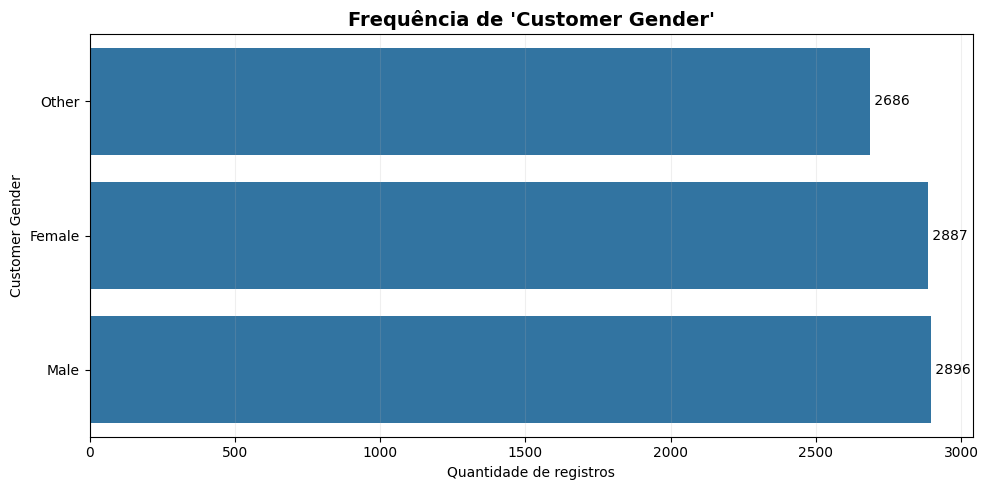


Variável: Product Purchased

Frequência absoluta:
Product Purchased
Canon EOS                         240
GoPro Hero                        228
Nest Thermostat                   225
Philips Hue Lights                221
Amazon Echo                       221
LG Smart TV                       219
Sony Xperia                       217
Roomba Robot Vacuum               216
Apple AirPods                     213
LG OLED                           213
iPhone                            212
Sony 4K HDR TV                    210
LG Washing Machine                208
Garmin Forerunner                 208
Canon DSLR Camera                 206
Nikon D                           204
Nintendo Switch Pro Controller    203
Google Pixel                      203
Fitbit Charge                     202
Sony PlayStation                  202
HP Pavilion                       200
Microsoft Office                  200
Dyson Vacuum Cleaner              198
Amazon Kindle                     198
Google Nest        

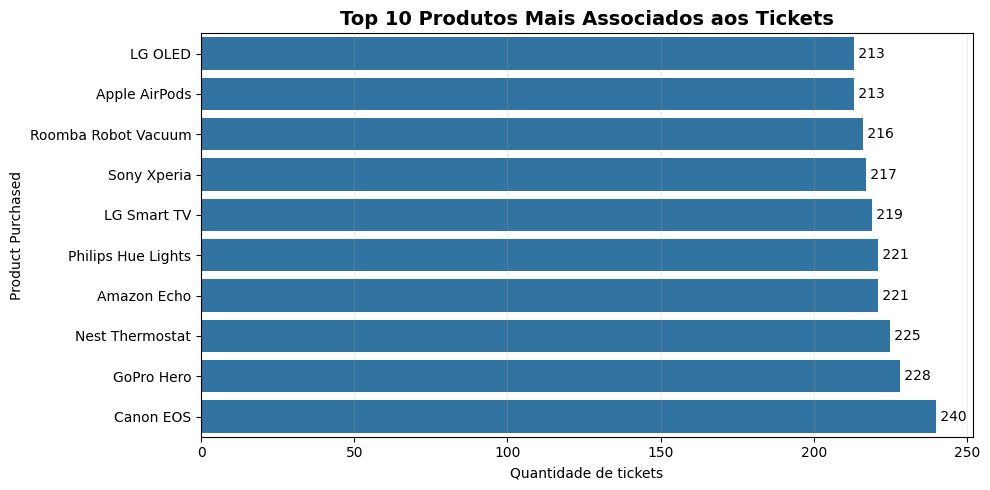


Variável: Ticket Type

Frequência absoluta:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Frequência relativa (%):
Ticket Type
Refund request          20.69
Technical issue         20.63
Cancellation request    20.01
Product inquiry         19.38
Billing inquiry         19.29
Name: proportion, dtype: float64


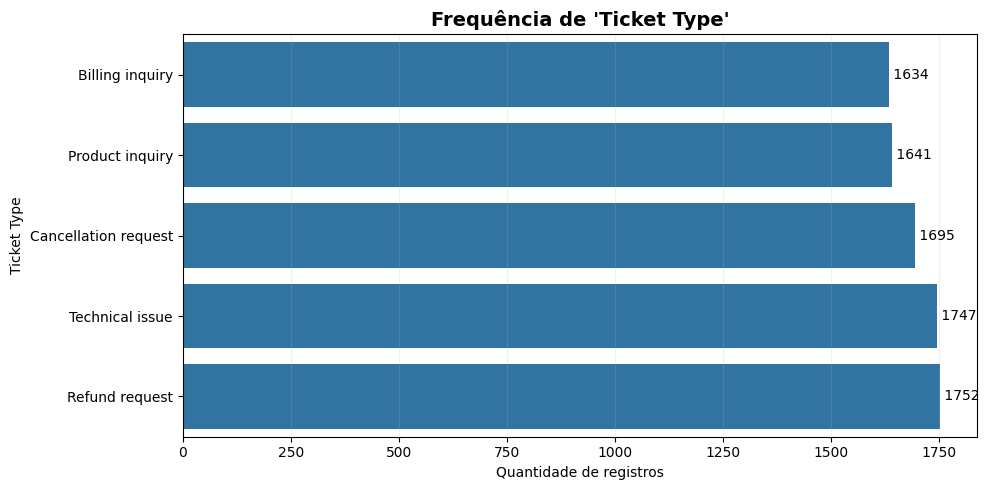


Variável: Ticket Status

Frequência absoluta:
Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

Frequência relativa (%):
Ticket Status
Pending Customer Response    34.02
Open                         33.29
Closed                       32.70
Name: proportion, dtype: float64


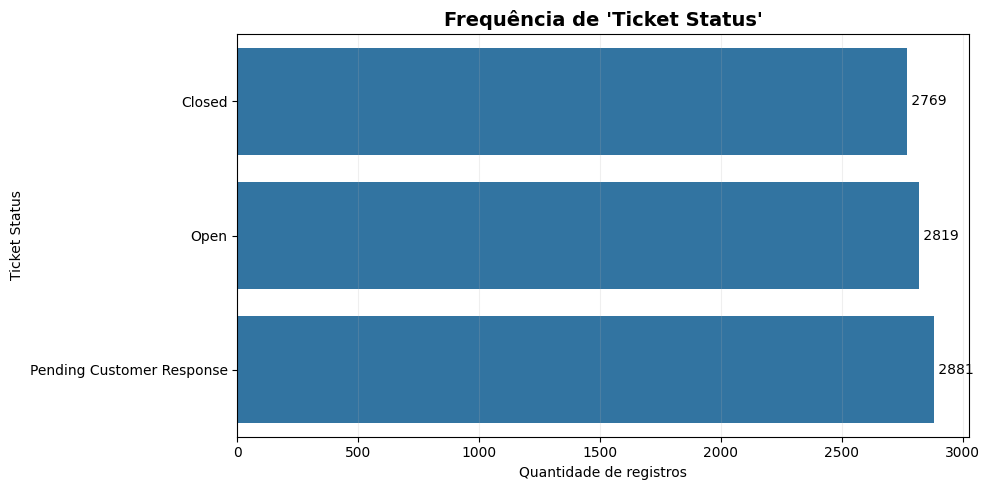


Variável: Ticket Priority

Frequência absoluta:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Frequência relativa (%):
Ticket Priority
Medium      25.88
Critical    25.14
High        24.62
Low         24.36
Name: proportion, dtype: float64


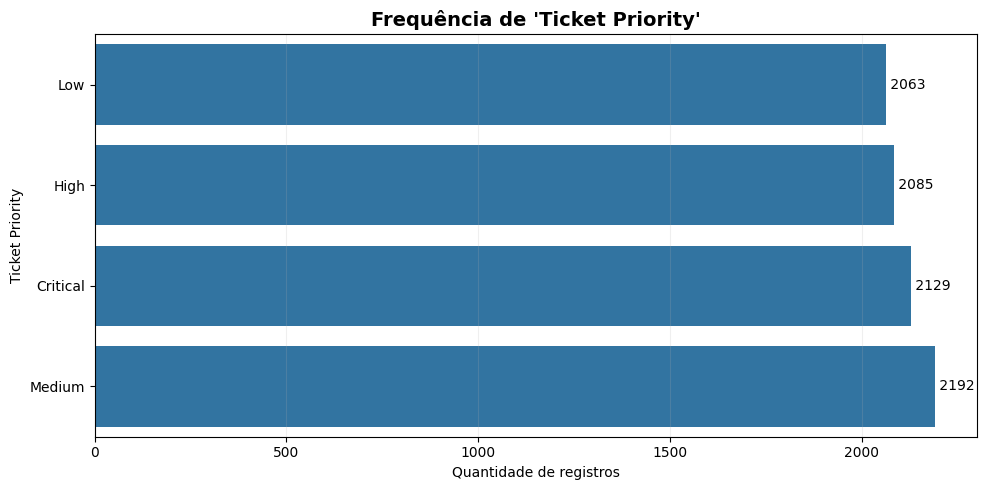


Variável: Ticket Channel

Frequência absoluta:
Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

Frequência relativa (%):
Ticket Channel
Email           25.30
Phone           25.17
Social media    25.04
Chat            24.48
Name: proportion, dtype: float64


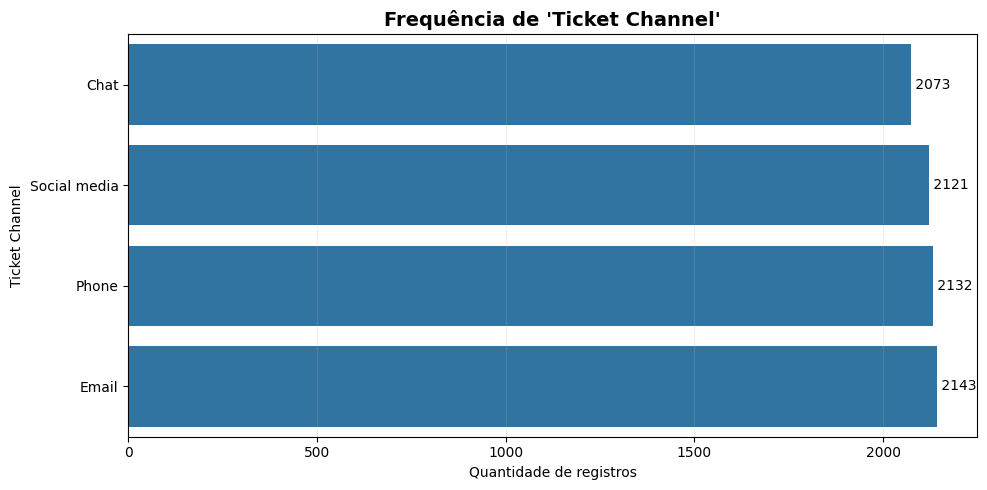


3. Categoria mais frequente

Categoria mais frequente da variável 'Customer Gender':
Categoria: Male
Quantidade: 2896
Percentual: 34.20%

Categoria mais frequente da variável 'Product Purchased':
Categoria: Canon EOS
Quantidade: 240
Percentual: 2.83%

Categoria mais frequente da variável 'Ticket Type':
Categoria: Refund request
Quantidade: 1752
Percentual: 20.69%

Categoria mais frequente da variável 'Ticket Status':
Categoria: Pending Customer Response
Quantidade: 2881
Percentual: 34.02%

Categoria mais frequente da variável 'Ticket Priority':
Categoria: Medium
Quantidade: 2192
Percentual: 25.88%

Categoria mais frequente da variável 'Ticket Channel':
Categoria: Email
Quantidade: 2143
Percentual: 25.30%

4. Resumo da distribuição das variáveis categóricas

Customer Gender:
Quantidade de categorias: 3
Categoria mais frequente: Male
Frequência: 2896 (34.20%)

Product Purchased:
Quantidade de categorias: 42
Categoria mais frequente: Canon EOS
Frequência: 240 (2.83%)

Ticket Type:
Quanti

In [6]:
colunas_categoricas = [
    "Customer Gender",
    "Product Purchased",
    "Ticket Type",
    "Ticket Status",
    "Ticket Priority",
    "Ticket Channel"
]



print_formatado(
    "1. Quantidade de categorias"
)

print(
    "\nQuantidade de categorias únicas por variável:"
)


quantidade_categorias = (
    df[colunas_categoricas]
    .nunique()
    .sort_values(ascending=False)
)


print(quantidade_categorias)


print("\nValores ausentes:")

for coluna in colunas_categoricas:

    ausentes = df[coluna].isna().sum()

    print(
        f"{coluna:<30}: "
        f"{ausentes}"
    )



print_formatado(
    "2. Frequência absoluta e relativa"
)


for coluna in colunas_categoricas:

    print(f"\n{'=' * 80}")
    print(f"Variável: {coluna}")
    print(f"{'=' * 80}")



    frequencia_absoluta = (
        df[coluna]
        .value_counts(dropna=False)
    )


    print("\nFrequência absoluta:")

    print(
        frequencia_absoluta
    )



    frequencia_relativa = (
        df[coluna]
        .value_counts(
            normalize=True,
            dropna=False
        )
        * 100
    )


    print("\nFrequência relativa (%):")

    print(
        frequencia_relativa.round(2)
    )



    dados_grafico = (
        frequencia_absoluta
        .sort_values(ascending=False)
    )



    if coluna == "Product Purchased":

        dados_grafico = (
            dados_grafico
            .head(10)
            .sort_values(ascending=True)
        )


        titulo = (
            "Top 10 Produtos Mais Associados aos Tickets"
        )

        eixo_x = (
            "Quantidade de tickets"
        )



    else:

        dados_grafico = (
            dados_grafico
            .sort_values(ascending=True)
        )


        titulo = (
            f"Frequência de '{coluna}'"
        )

        eixo_x = (
            "Quantidade de registros"
        )


    plt.figure(
        figsize=(10, 5)
    )


    ax = sns.barplot(
        x=dados_grafico.values,
        y=dados_grafico.index.astype(str)
    )


    plt.title(
        titulo,
        fontsize=14,
        fontweight="bold"
    )


    plt.xlabel(
        eixo_x
    )

    plt.ylabel(
        coluna
    )


    plt.grid(
        axis="x",
        alpha=0.2
    )



    for i, valor in enumerate(
        dados_grafico.values
    ):

        plt.text(
            valor,
            i,
            f" {valor}",
            va="center",
            fontsize=10
        )


    plt.tight_layout()
    plt.show()



print_formatado(
    "3. Categoria mais frequente"
)


for coluna in colunas_categoricas:

    frequencias = (
        df[coluna]
        .value_counts(
            dropna=False
        )
    )


    categoria_mais_frequente = (
        frequencias.index[0]
    )


    quantidade = (
        frequencias.iloc[0]
    )


    percentual = (
        quantidade /
        len(df)
        * 100
    )


    print(
        f"\nCategoria mais frequente "
        f"da variável '{coluna}':"
    )


    print(
        f"Categoria: "
        f"{categoria_mais_frequente}"
    )


    print(
        f"Quantidade: "
        f"{quantidade}"
    )


    print(
        f"Percentual: "
        f"{percentual:.2f}%"
    )



print_formatado(
    "4. Resumo da distribuição das variáveis categóricas"
)


for coluna in colunas_categoricas:

    frequencias = (
        df[coluna]
        .value_counts()
    )


    categoria_maior = (
        frequencias.index[0]
    )

    quantidade_maior = (
        frequencias.iloc[0]
    )

    percentual_maior = (
        quantidade_maior /
        len(df)
        * 100
    )


    print(
        f"\n{coluna}:"
    )

    print(
        f"Quantidade de categorias: "
        f"{df[coluna].nunique()}"
    )

    print(
        f"Categoria mais frequente: "
        f"{categoria_maior}"
    )

    print(
        f"Frequência: "
        f"{quantidade_maior} "
        f"({percentual_maior:.2f}%)"
    )


print("Ver Markdown")

# Observações Análise Univariada

# **Análise Multivariada**

## **Variáveis numéricas**


1. Correlação linear entre variáveis numéricas:

Matriz de correlação de Pearson:
                              Customer Age  Customer Satisfaction Rating
Customer Age                         1.000                        -0.004
Customer Satisfaction Rating        -0.004                         1.000

Correlação entre as variáveis:
Customer Age x Customer Satisfaction Rating: r = -0.004 (negativa)


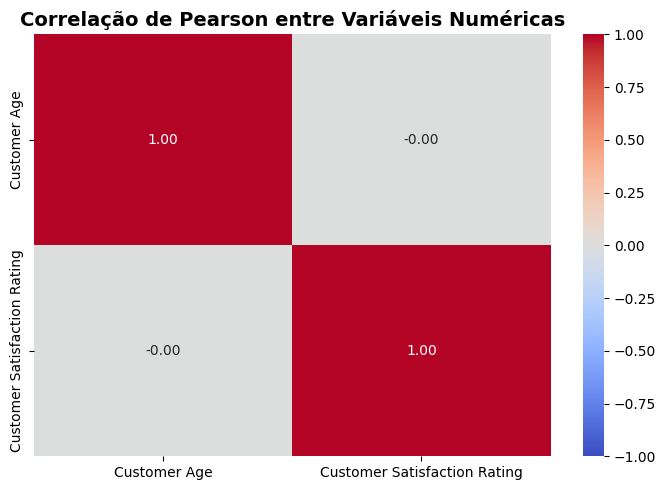


2. Correlação monotônica entre variáveis numéricas:

Matriz de correlação de Spearman:
                              Customer Age  Customer Satisfaction Rating
Customer Age                         1.000                        -0.004
Customer Satisfaction Rating        -0.004                         1.000

Customer Age x Customer Satisfaction Rating: ρ = -0.004 (negativa)


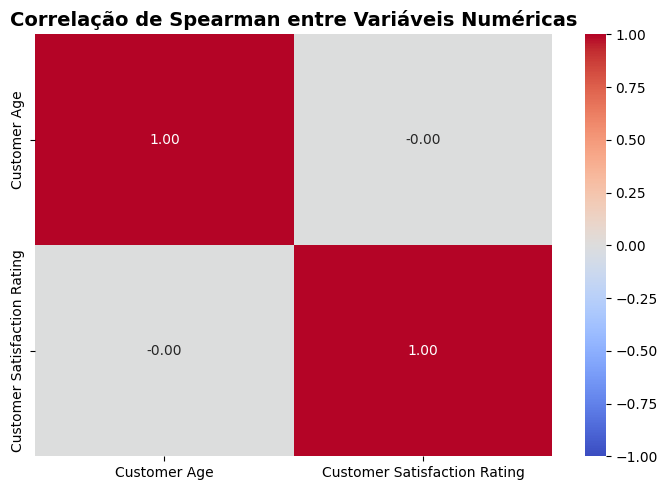

Ver Markdown


In [7]:


colunas_numericas = [
    "Customer Age",
    "Customer Satisfaction Rating"
]



print_formatado("1. Correlação linear entre variáveis numéricas:")

matriz_pearson = df[colunas_numericas].corr(method="pearson")

print("\nMatriz de correlação de Pearson:")
print(matriz_pearson.round(3))



print("\nCorrelação entre as variáveis:")

valor_pearson = matriz_pearson.loc[
    "Customer Age",
    "Customer Satisfaction Rating"
]

if valor_pearson > 0:
    sinal = "positiva"
elif valor_pearson < 0:
    sinal = "negativa"
else:
    sinal = "nula"

print(
    f"Customer Age x Customer Satisfaction Rating: "
    f"r = {valor_pearson:.3f} ({sinal})"
)



plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz_pearson,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.title(
    "Correlação de Pearson entre Variáveis Numéricas",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()



print_formatado("2. Correlação monotônica entre variáveis numéricas:")

matriz_spearman = df[colunas_numericas].corr(
    method="spearman"
)

print("\nMatriz de correlação de Spearman:")
print(matriz_spearman.round(3))


valor_spearman = matriz_spearman.loc[
    "Customer Age",
    "Customer Satisfaction Rating"
]

if valor_spearman > 0:
    sinal = "positiva"
elif valor_spearman < 0:
    sinal = "negativa"
else:
    sinal = "nula"

print(
    f"\nCustomer Age x Customer Satisfaction Rating: "
    f"ρ = {valor_spearman:.3f} ({sinal})"
)


plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz_spearman,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.title(
    "Correlação de Spearman entre Variáveis Numéricas",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


print("Ver Markdown")

### **Observações da Análise Multivariada - Variáveis Numéricas**




## **Variáveis categóricas**

In [8]:

colunas_categoricas = [
    "Customer Gender",
    "Product Purchased",
    "Ticket Type",
    "Ticket Status",
    "Ticket Priority",
    "Ticket Channel"
]

alvo_categorico = "Ticket Status"



print_formatado(
    "1. Associação entre variáveis categóricas e Ticket Status:"
)

for coluna in colunas_categoricas:

    if coluna == alvo_categorico:
        continue

    print(f"\n{'=' * 80}")
    print(f"{coluna} x {alvo_categorico}")
    print(f"{'=' * 80}")



    tabela_contingencia = pd.crosstab(
        df[coluna],
        df[alvo_categorico]
    )

    print("\nTabela de contingência:")
    print(tabela_contingencia)



    chi2, p_valor, graus_liberdade, frequencias_esperadas = (
        chi2_contingency(tabela_contingencia)
    )

    print("\nTeste Qui-quadrado:")

    print(f"χ² = {chi2:.3f}")
    print(f"P-valor = {p_valor:.5f}")
    print(f"Graus de liberdade = {graus_liberdade}")



    n = tabela_contingencia.to_numpy().sum()

    menor_dimensao = min(
        tabela_contingencia.shape[0] - 1,
        tabela_contingencia.shape[1] - 1
    )

    if menor_dimensao > 0:
        v_cramer = np.sqrt(
            chi2 / (n * menor_dimensao)
        )
    else:
        v_cramer = np.nan

    print("\nV de Cramér:")
    print(f"V de Cramér = {v_cramer:.3f}")



print_formatado(
    "2. Associação entre variáveis categóricas independentes:"
)

for i in range(len(colunas_categoricas)):

    for j in range(i + 1, len(colunas_categoricas)):

        coluna_1 = colunas_categoricas[i]
        coluna_2 = colunas_categoricas[j]

        if coluna_1 == coluna_2:
            continue

        print(f"\n{'=' * 80}")
        print(f"{coluna_1} x {coluna_2}")
        print(f"{'=' * 80}")




        tabela_contingencia = pd.crosstab(
            df[coluna_1],
            df[coluna_2]
        )

        print("\nTabela de contingência:")
        print(tabela_contingencia)




        chi2, p_valor, graus_liberdade, frequencias_esperadas = (
            chi2_contingency(tabela_contingencia)
        )

        print("\nTeste Qui-quadrado:")

        print(f"χ² = {chi2:.3f}")
        print(f"P-valor = {p_valor:.5f}")
        print(f"Graus de liberdade = {graus_liberdade}")



        n = tabela_contingencia.to_numpy().sum()

        menor_dimensao = min(
            tabela_contingencia.shape[0] - 1,
            tabela_contingencia.shape[1] - 1
        )

        if menor_dimensao > 0:

            v_cramer = np.sqrt(
                chi2 / (n * menor_dimensao)
            )

        else:

            v_cramer = np.nan

        print("\nV de Cramér:")
        print(f"V de Cramér = {v_cramer:.3f}")


print("Ver Markdown")


1. Associação entre variáveis categóricas e Ticket Status:

Customer Gender x Ticket Status

Tabela de contingência:
Ticket Status    Closed  Open  Pending Customer Response
Customer Gender                                         
Female              984   946                        957
Male                916   989                        991
Other               869   884                        933

Teste Qui-quadrado:
χ² = 4.884
P-valor = 0.29945
Graus de liberdade = 4

V de Cramér:
V de Cramér = 0.017

Product Purchased x Ticket Status

Tabela de contingência:
Ticket Status                   Closed  Open  Pending Customer Response
Product Purchased                                                      
Adobe Photoshop                     63    58                         60
Amazon Echo                         72    68                         81
Amazon Kindle                       66    62                         70
Apple AirPods                       74    75                         6

### **Observações da Análise de Associação entre Variáveis Categóricas**



# **Identificação de Outliers e Anomalias**

## **Variáveis numéricas**


1. Selecionar método de identificação de outliers

1.1. Q-Q Plot, Assimetria e Teste de Shapiro-Wilk

Variável: Customer Age
Quantidade de valores válidos: 8469


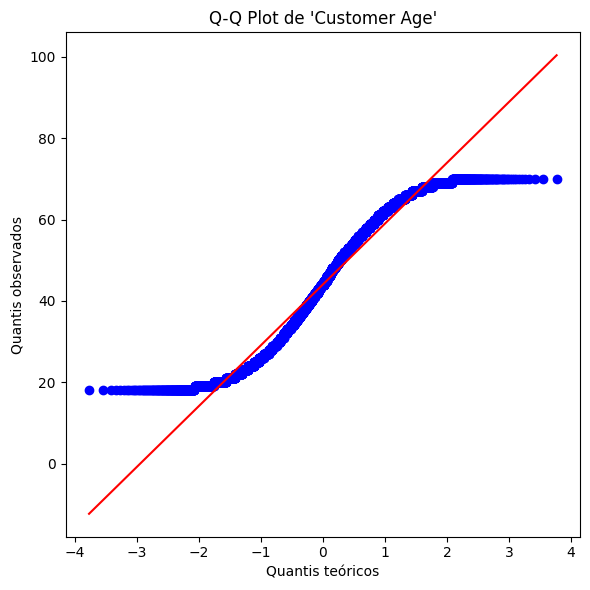

Assimetria: -0.0172
Estatística W: 0.9539
P-valor: 4.35466e-37
Conclusão: rejeita-se a hipótese de normalidade ao nível de 5%.

Variável: Customer Satisfaction Rating
Quantidade de valores válidos: 2769


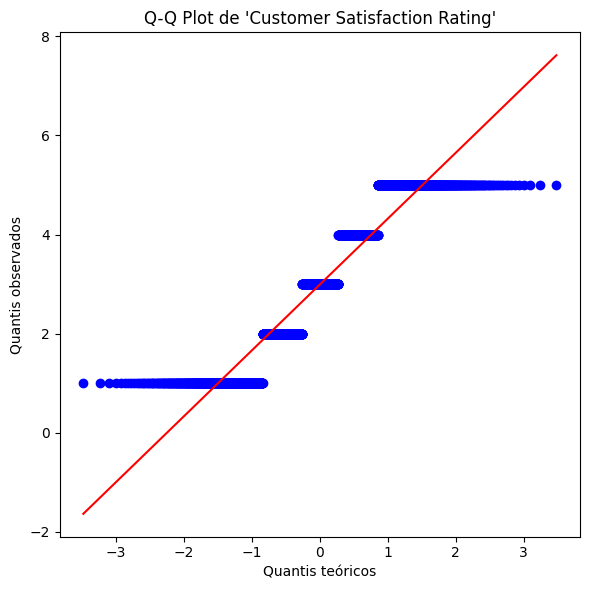

Assimetria: 0.0084
Estatística W: 0.8896
P-valor: 1.10463e-40
Conclusão: rejeita-se a hipótese de normalidade ao nível de 5%.


In [9]:
from scipy import stats
import matplotlib.pyplot as plt


colunas_numericas = [
    "Customer Age",
    "Customer Satisfaction Rating"
]


alpha = 0.05
tamanho_maximo_shapiro = 5000

resultados_normalidade = {}


print_formatado(
    "1. Selecionar método de identificação de outliers"
)


print_formatado(
    "1.1. Q-Q Plot, Assimetria e Teste de Shapiro-Wilk"
)


for coluna in colunas_numericas:

    dados = df[coluna].dropna()

    print(f"\nVariável: {coluna}")

    print(
        f"Quantidade de valores válidos: "
        f"{len(dados)}"
    )


    # Q-Q Plot

    plt.figure(
        figsize=(6, 6)
    )

    stats.probplot(
        dados,
        dist="norm",
        plot=plt
    )

    plt.title(
        f"Q-Q Plot de '{coluna}'"
    )

    plt.xlabel(
        "Quantis teóricos"
    )

    plt.ylabel(
        "Quantis observados"
    )

    plt.tight_layout()
    plt.show()


    # Assimetria

    assimetria = stats.skew(
        dados,
        bias=False,
        nan_policy="omit"
    )

    print(
        f"Assimetria: "
        f"{assimetria:.4f}"
    )


    # Para conjuntos muito grandes,
    # utiliza-se uma amostra no Shapiro-Wilk

    if len(dados) > tamanho_maximo_shapiro:

        dados_teste = dados.sample(
            n=tamanho_maximo_shapiro,
            random_state=1
        )

    else:

        dados_teste = dados


    estatistica_w, p_valor = (
        stats.shapiro(dados_teste)
    )


    resultados_normalidade[coluna] = {
        "W": estatistica_w,
        "p_valor": p_valor
    }


    print(
        f"Estatística W: "
        f"{estatistica_w:.4f}"
    )

    print(
        f"P-valor: "
        f"{p_valor:.6g}"
    )


    if p_valor < alpha:

        print(
            "Conclusão: rejeita-se a hipótese "
            "de normalidade ao nível de 5%."
        )

    else:

        print(
            "Conclusão: não há evidências suficientes "
            "para rejeitar a hipótese de normalidade "
            "ao nível de 5%."
        )

### **Observações – Identificação de Outliers e Anomalias**

### 1. Seleção do método de identificação de outliers

Foram analisadas as variáveis numéricas `Customer Age` e `Customer Satisfaction Rating` por meio de Q-Q Plot, assimetria e teste de Shapiro-Wilk.

A variável `Customer Age` apresentou assimetria próxima de zero, indicando uma distribuição aproximadamente simétrica. Entretanto, o Q-Q Plot e o teste de Shapiro-Wilk indicaram diferença em relação a uma distribuição normal, com p-valor inferior a 0,05.

A variável `Customer Satisfaction Rating` também apresentou assimetria próxima de zero. Entretanto, trata-se de uma variável discreta e ordinal, limitada aos valores de 1 a 5. O teste de Shapiro-Wilk também apresentou p-valor inferior a 0,05.

Dessa forma, não foi assumida normalidade para essas variáveis.

Para identificação de possíveis valores extremos será utilizado o método IQR (Interquartile Range), que não exige a hipótese de distribuição normal.

In [10]:
variaveis_iqr = [
    "Customer Age",
    "Customer Satisfaction Rating"
]


print_formatado(
    "2. Identificar possíveis outliers com IQR"
)


outliers_por_coluna = {}
indices_outliers = set()


for coluna in variaveis_iqr:

    dados = df[coluna].dropna()


    q1 = dados.quantile(0.25)
    q3 = dados.quantile(0.75)

    iqr = q3 - q1


    limite_inferior = (
        q1 - 1.5 * iqr
    )

    limite_superior = (
        q3 + 1.5 * iqr
    )


    mascara_outliers = (
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    )


    outliers_coluna = (
        df.loc[mascara_outliers]
        .copy()
    )


    outliers_por_coluna[coluna] = (
        outliers_coluna
    )


    indices_outliers.update(
        outliers_coluna.index
    )


    print(f"\nVariável: {coluna}")

    print(
        f"Q1: "
        f"{q1:.2f}"
    )

    print(
        f"Q3: "
        f"{q3:.2f}"
    )

    print(
        f"IQR: "
        f"{iqr:.2f}"
    )

    print(
        f"Limite inferior: "
        f"{limite_inferior:.2f}"
    )

    print(
        f"Limite superior: "
        f"{limite_superior:.2f}"
    )

    print(
        f"Quantidade de possíveis outliers: "
        f"{len(outliers_coluna)}"
    )


    if len(outliers_coluna) > 0:

        display(
            outliers_coluna[
                ["Ticket ID", coluna]
            ].head(10)
        )

    else:

        print(
            "Nenhum possível outlier "
            "identificado pelo método IQR."
        )


print(
    "\nQuantidade total de registros "
    "identificados como possíveis outliers:"
)

print(
    len(indices_outliers)
)


2. Identificar possíveis outliers com IQR

Variável: Customer Age
Q1: 31.00
Q3: 57.00
IQR: 26.00
Limite inferior: -8.00
Limite superior: 96.00
Quantidade de possíveis outliers: 0
Nenhum possível outlier identificado pelo método IQR.

Variável: Customer Satisfaction Rating
Q1: 2.00
Q3: 4.00
IQR: 2.00
Limite inferior: -1.00
Limite superior: 7.00
Quantidade de possíveis outliers: 0
Nenhum possível outlier identificado pelo método IQR.

Quantidade total de registros identificados como possíveis outliers:
0


### **Observações – Identificação de Outliers Numéricos**

O método IQR foi aplicado às duas variáveis numéricas analisadas.

### `Customer Age`

- Q1 = 31 anos.
- Q3 = 57 anos.
- IQR = 26 anos.
- Limite inferior = -8 anos.
- Limite superior = 96 anos.
- Os valores observados no dataset variam de 18 a 70 anos.

Portanto, nenhum registro foi identificado como outlier de idade pelo método IQR.

### `Customer Satisfaction Rating`

- Q1 = 2.
- Q3 = 4.
- IQR = 2.
- Limite inferior = -1.
- Limite superior = 7.
- Os valores observados variam de 1 a 5.

Portanto, nenhum registro foi identificado como outlier de satisfação pelo método IQR.

Dessa forma, não foi necessária a remoção de registros por valores extremos nessas duas variáveis.

## **Variáveis Categóricas**

In [11]:
colunas_categoricas = [
    "Customer Gender",
    "Product Purchased",
    "Ticket Type",
    "Ticket Status",
    "Ticket Priority",
    "Ticket Channel"
]


nivel_desequilibrio = 2
limite_categoria_rara = 0.01


print_formatado(
    "1. Identificar categorias raras"
)


for coluna in colunas_categoricas:

    frequencia_relativa = (
        df[coluna]
        .value_counts(
            normalize=True,
            dropna=False
        )
    )


    categorias_raras = (
        frequencia_relativa[
            frequencia_relativa <
            limite_categoria_rara
        ]
    )


    print(
        f"\nVariável: {coluna}"
    )


    if categorias_raras.empty:

        print(
            "Nenhuma categoria com frequência "
            "inferior a 1%."
        )

    else:

        print(
            "Categorias com frequência "
            "inferior a 1%:"
        )

        print(
            (
                categorias_raras * 100
            )
            .round(2)
            .astype(str)
            + "%"
        )


print_formatado(
    "2. Identificar possível desequilíbrio entre categorias"
)


for coluna in colunas_categoricas:

    contagem = (
        df[coluna]
        .value_counts(
            dropna=False
        )
    )


    maior_frequencia = (
        contagem.max()
    )

    menor_frequencia = (
        contagem.min()
    )


    razao_desequilibrio = (
        maior_frequencia /
        menor_frequencia
    )


    print(
        f"\nVariável: {coluna}"
    )

    print(
        f"Maior frequência: "
        f"{maior_frequencia}"
    )

    print(
        f"Menor frequência: "
        f"{menor_frequencia}"
    )

    print(
        f"Razão maior/menor: "
        f"{razao_desequilibrio:.2f}"
    )


    if (
        razao_desequilibrio >=
        nivel_desequilibrio
    ):

        print(
            "Conclusão: possível "
            "desequilíbrio entre categorias."
        )

    else:

        print(
            "Conclusão: não foi identificado "
            "desequilíbrio relevante."
        )


1. Identificar categorias raras

Variável: Customer Gender
Nenhuma categoria com frequência inferior a 1%.

Variável: Product Purchased
Nenhuma categoria com frequência inferior a 1%.

Variável: Ticket Type
Nenhuma categoria com frequência inferior a 1%.

Variável: Ticket Status
Nenhuma categoria com frequência inferior a 1%.

Variável: Ticket Priority
Nenhuma categoria com frequência inferior a 1%.

Variável: Ticket Channel
Nenhuma categoria com frequência inferior a 1%.

2. Identificar possível desequilíbrio entre categorias

Variável: Customer Gender
Maior frequência: 2896
Menor frequência: 2686
Razão maior/menor: 1.08
Conclusão: não foi identificado desequilíbrio relevante.

Variável: Product Purchased
Maior frequência: 240
Menor frequência: 178
Razão maior/menor: 1.35
Conclusão: não foi identificado desequilíbrio relevante.

Variável: Ticket Type
Maior frequência: 1752
Menor frequência: 1634
Razão maior/menor: 1.07
Conclusão: não foi identificado desequilíbrio relevante.

Variáve

### **Observações – Categorias Raras e Desequilíbrio**

Foram analisadas as variáveis categóricas:

- `Customer Gender`
- `Product Purchased`
- `Ticket Type`
- `Ticket Status`
- `Ticket Priority`
- `Ticket Channel`

Foi utilizado como critério de categoria rara uma frequência inferior a 1% dos registros.

Nenhuma das categorias analisadas apresentou frequência inferior a 1%.

Também foi utilizada a razão entre a categoria mais frequente e a menos frequente para verificar possíveis desequilíbrios.

Considerando como referência uma razão igual ou superior a 2, nenhuma das variáveis apresentou desequilíbrio relevante.

Mesmo `Product Purchased`, que possui 42 categorias diferentes, apresentou uma distribuição relativamente uniforme, sem produtos com frequência inferior a 1%.

Portanto, não foi necessário remover ou agrupar categorias.

In [12]:
print_formatado(
    "3. Identificar anomalias nas variáveis temporais"
)


# Garante que as colunas estejam no formato datetime

df["First Response Time"] = pd.to_datetime(
    df["First Response Time"],
    errors="coerce"
)

df["Time to Resolution"] = pd.to_datetime(
    df["Time to Resolution"],
    errors="coerce"
)


# Seleciona tickets fechados que possuem
# os dois timestamps preenchidos

tickets_fechados = df[
    (df["Ticket Status"] == "Closed") &
    (df["First Response Time"].notna()) &
    (df["Time to Resolution"].notna())
].copy()


# Calcula a diferença entre resolução
# e primeira resposta

tickets_fechados[
    "Resolution Duration"
] = (
    tickets_fechados[
        "Time to Resolution"
    ]
    -
    tickets_fechados[
        "First Response Time"
    ]
)


# Identifica durações negativas

mascara_duracao_negativa = (
    tickets_fechados[
        "Resolution Duration"
    ]
    < pd.Timedelta(0)
)


quantidade_negativa = (
    mascara_duracao_negativa
    .sum()
)


quantidade_zero = (
    (
        tickets_fechados[
            "Resolution Duration"
        ]
        == pd.Timedelta(0)
    )
    .sum()
)


quantidade_positiva = (
    (
        tickets_fechados[
            "Resolution Duration"
        ]
        > pd.Timedelta(0)
    )
    .sum()
)


percentual_negativa = (
    quantidade_negativa /
    len(tickets_fechados)
) * 100


print(
    f"Tickets fechados analisados: "
    f"{len(tickets_fechados)}"
)


print(
    f"Resolução posterior à primeira resposta: "
    f"{quantidade_positiva}"
)


print(
    f"Resolução no mesmo instante da primeira resposta: "
    f"{quantidade_zero}"
)


print(
    f"Resolução anterior à primeira resposta: "
    f"{quantidade_negativa}"
)


print(
    f"Percentual de anomalias temporais: "
    f"{percentual_negativa:.2f}%"
)


print(
    "\nExemplos de registros com "
    "resolução anterior à primeira resposta:"
)


display(
    tickets_fechados.loc[
        mascara_duracao_negativa,
        [
            "Ticket ID",
            "Ticket Status",
            "First Response Time",
            "Time to Resolution",
            "Resolution Duration"
        ]
    ].head(10)
)


3. Identificar anomalias nas variáveis temporais
Tickets fechados analisados: 2769
Resolução posterior à primeira resposta: 1402
Resolução no mesmo instante da primeira resposta: 2
Resolução anterior à primeira resposta: 1365
Percentual de anomalias temporais: 49.30%

Exemplos de registros com resolução anterior à primeira resposta:


,Ticket ID,Ticket Status,First Response Time,Time to Resolution,Resolution Duration
3,4,Closed,2023-06-01 07:29:40,2023-06-01 01:57:40,-1 days +18:28:00
10,11,Closed,2023-06-01 17:46:49,2023-05-31 23:51:49,-1 days +06:05:00
11,12,Closed,2023-06-01 12:05:51,2023-06-01 09:27:51,-1 days +21:22:00
14,15,Closed,2023-06-01 06:22:55,2023-05-31 23:08:55,-1 days +16:46:00
16,17,Closed,2023-06-01 19:46:59,2023-06-01 15:58:59,-1 days +20:12:00
35,36,Closed,2023-06-01 07:56:25,2023-06-01 00:14:25,-1 days +16:18:00
38,39,Closed,2023-06-01 18:45:30,2023-05-31 21:53:30,-1 days +03:08:00
41,42,Closed,2023-06-01 20:25:34,2023-06-01 14:43:34,-1 days +18:18:00
44,45,Closed,2023-06-01 05:58:39,2023-06-01 03:19:39,-1 days +21:21:00
47,48,Closed,2023-06-01 07:16:45,2023-06-01 05:59:45,-1 days +22:43:00


### **Observações – Anomalias Temporais**

Após a conversão de `First Response Time` e `Time to Resolution` para o formato `datetime`, foi possível comparar cronologicamente os dois timestamps nos tickets fechados.

Foram analisados 2.769 tickets com status `Closed`, pois esses registros possuem tanto a primeira resposta quanto o momento da resolução preenchidos.

Os resultados mostraram:

- 1.402 tickets com resolução posterior à primeira resposta.
- 2 tickets com resolução registrada no mesmo instante da primeira resposta.
- 1.365 tickets com resolução anterior à primeira resposta.

Portanto, aproximadamente 49,30% dos tickets fechados apresentam uma inconsistência temporal em que o momento registrado como resolução ocorre antes da primeira resposta.

Esse comportamento representa uma anomalia de qualidade dos dados, pois cronologicamente a resolução de um chamado não deveria ocorrer antes da primeira resposta registrada.

Os registros não foram removidos automaticamente, pois a origem da inconsistência não pode ser determinada apenas por meio do dataset. A anomalia foi identificada e documentada para evitar interpretações incorretas em análises de duração.

Consequentemente, não é adequado calcular diretamente um tempo médio de resolução utilizando a diferença entre `Time to Resolution` e `First Response Time` sem antes tratar ou investigar essas inconsistências.

# **Conclusões**

## **Principais Achados**

A Análise Exploratória de Dados foi realizada sobre um conjunto contendo **8.469 tickets de suporte e 17 variáveis**.

### Qualidade dos dados

Não foram identificados registros completamente duplicados nem identificadores `Ticket ID` repetidos. Dessa forma, os 8.469 registros originais foram preservados.

Foram encontrados valores ausentes em quatro variáveis:

- `Resolution`: 5.700 valores ausentes (67,30%).
- `Time to Resolution`: 5.700 valores ausentes (67,30%).
- `First Response Time`: 2.819 valores ausentes (33,29%).
- `Customer Satisfaction Rating`: 5.700 valores ausentes (67,30%).

A análise mostrou que esses valores ausentes estão relacionados ao estado dos tickets.

Os 2.769 tickets com status `Closed` possuem resolução, primeira resposta, momento da resolução e avaliação de satisfação preenchidos.

Os tickets com status `Open` ainda não possuem essas informações, enquanto os tickets com status `Pending Customer Response` possuem primeira resposta, mas ainda não possuem resolução ou avaliação de satisfação.

Por esse motivo, os valores ausentes foram preservados, evitando imputações artificiais.

### Preparação dos dados

As variáveis categóricas foram convertidas para o tipo `category`.

As variáveis:

- `Date of Purchase`
- `First Response Time`
- `Time to Resolution`

foram convertidas para `datetime64[ns]`.

Não foram encontrados valores inválidos em `Customer Age` ou `Customer Satisfaction Rating`.

### Análise das variáveis numéricas

A idade dos clientes varia entre 18 e 70 anos, com média aproximada de 44 anos.

A variável `Customer Satisfaction Rating` varia entre 1 e 5 e possui 2.769 observações válidas.

A correlação entre `Customer Age` e `Customer Satisfaction Rating` foi praticamente nula:

- Pearson ≈ -0,004.
- Spearman ≈ -0,004.

Portanto, não foram encontradas evidências de uma relação linear ou monotônica relevante entre idade e satisfação dos clientes.

É importante observar que a satisfação está disponível somente para tickets fechados.

### Associação entre variáveis categóricas

Foram aplicados testes de Qui-quadrado e V de Cramér para investigar possíveis associações entre as variáveis categóricas.

As associações analisadas apresentaram magnitudes pequenas e não foram encontradas evidências de relações fortes entre as principais variáveis categóricas consideradas.

### Outliers numéricos

O método IQR foi utilizado para analisar possíveis valores extremos em:

- `Customer Age`
- `Customer Satisfaction Rating`

Nenhuma das duas variáveis apresentou valores classificados como outliers pelo critério de 1,5 vezes o IQR.

Portanto, nenhuma observação foi removida por esse critério.

### Categorias raras e desequilíbrio

Foram investigadas categorias com frequência inferior a 1%.

Nenhuma categoria das variáveis analisadas apresentou frequência inferior a esse limite.

Também não foi identificado desequilíbrio relevante entre as categorias utilizando como critério uma razão maior/menor frequência igual ou superior a 2.

Dessa forma, não foi necessário agrupar ou remover categorias.

### Anomalias temporais

Foi identificada uma inconsistência relevante nas variáveis temporais.

Entre os 2.769 tickets fechados:

- 1.402 possuem resolução posterior à primeira resposta.
- 2 possuem os dois timestamps no mesmo instante.
- 1.365 possuem `Time to Resolution` anterior a `First Response Time`.

Isso significa que aproximadamente **49,30% dos tickets fechados apresentam uma inconsistência temporal**.

Esses registros não foram removidos automaticamente, pois o dataset não fornece informações suficientes para determinar qual dos timestamps está incorreto.

A inconsistência deve ser considerada antes de qualquer análise que dependa do cálculo da duração entre primeira resposta e resolução.

## **Operações realizadas**

Durante a Análise Exploratória de Dados foram realizadas:

- inspeção da estrutura e dos tipos de dados;
- identificação de valores ausentes;
- verificação de registros duplicados;
- verificação de identificadores duplicados;
- análise de possíveis inconsistências categóricas;
- verificação de valores numéricos inválidos;
- conversão das variáveis temporais;
- análise univariada das variáveis numéricas e categóricas;
- análise de correlação de Pearson e Spearman;
- aplicação do teste de Qui-quadrado;
- cálculo do V de Cramér;
- análise de normalidade;
- identificação de possíveis outliers pelo método IQR;
- identificação de categorias raras;
- análise de desequilíbrio entre categorias;
- identificação de inconsistências temporais.

## **Conclusão Geral**

O conjunto de dados apresenta boa consistência em relação a duplicatas, valores numéricos e categorias.

Os valores ausentes possuem forte relação com o status operacional dos tickets e, portanto, sua manutenção é justificável.

Não foram encontrados outliers numéricos pelo método IQR nem categorias raras que necessitassem agrupamento.

Entretanto, foi identificada uma quantidade significativa de inconsistências entre os timestamps de primeira resposta e resolução. Essa característica deve ser considerada antes da utilização das variáveis temporais em análises de duração ou em modelos posteriores.



---



---



---



# Hipóteses sobre as intenções dos usuários

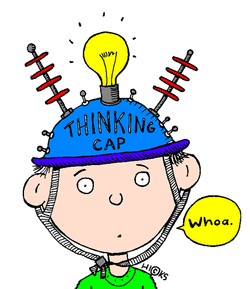

## Hipótese 1 – Os usuários procuram o suporte principalmente para resolver situações relacionadas ao pós-compra

A distribuição da variável Ticket Type mostra que as solicitações estão divididas de maneira bastante equilibrada entre Refund request (20,69%), Technical issue (20,63%), Cancellation request (20,01%), Product inquiry (19,38%) e Billing inquiry (19,29%).

Além disso, entre os assuntos mais frequentes aparecem Refund request, Software bug, Delivery problem, Hardware issue, Battery life, Network problem e Data loss.

Diante desse padrão, pode-se formular a hipótese de que uma parcela importante dos usuários procura o suporte após a compra, quando encontra algum problema relacionado ao funcionamento do produto, à entrega, ao pagamento ou à necessidade de reembolso.

## Hipótese 2 – Parte dos usuários procura orientação para instalar, configurar ou verificar a compatibilidade dos produtos

Entre os assuntos mais frequentes dos tickets estão Product compatibility, Installation support, Product setup, Product recommendation e Peripheral compatibility.

Esse comportamento permite levantar a hipótese de que parte dos usuários não procura o suporte apenas quando ocorre uma falha, mas também para obter orientação sobre como instalar, configurar ou utilizar corretamente os produtos.

Assim, uma das intenções dos usuários pode ser reduzir dúvidas técnicas e obter assistência para utilizar o produto de maneira adequada.

## Hipótese 3 – Uma parcela dos usuários demonstra intenção de modificar ou encerrar a relação de compra

Os tipos Refund request e Cancellation request representam, respectivamente, aproximadamente 20,69% e 20,01% dos tickets. Além disso, Refund request aparece como o assunto individual mais frequente, com 576 registros, enquanto Cancellation request também está entre os assuntos recorrentes.

A partir desses padrões, pode-se levantar a hipótese de que uma parcela relevante dos usuários procura o atendimento com a intenção de desfazer ou modificar uma transação já realizada, seja solicitando reembolso, cancelamento ou resolução de algum problema financeiro.

Esse comportamento pode estar relacionado a problemas com o produto, cobrança, entrega ou expectativas não atendidas, embora os dados analisados de forma univariada não permitam determinar diretamente a causa.

## Hipótese 4 – Os usuários esperam encontrar suporte por diferentes canais de atendimento

A distribuição da variável Ticket Channel é bastante equilibrada:

Email: aproximadamente 25,30%;
Phone: aproximadamente 25,17%;
Social media: aproximadamente 25,04%;
Chat: aproximadamente 24,48%.

Não existe, portanto, um único canal claramente dominante.

Esse padrão permite formular a hipótese de que os usuários possuem diferentes preferências para entrar em contato com o suporte e esperam conseguir atendimento independentemente do canal escolhido. Dessa forma, a disponibilidade de uma estratégia de atendimento multicanal pode ser importante para atender aos diferentes perfis de usuários.